<a href="https://colab.research.google.com/github/sittana-afifi/KTT-Fellow-Hackathon---G1---T2.1-Compressed-Crop-Disease-Classifier/blob/main/predict_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install onnx onnxscript onnxruntime

In [ ]:
import torch.nn as nn
from torchvision import models

# 1. Load the SMALL version explicitly
model = models.mobilenet_v3_small(weights='IMAGENET1K_V1')

# 2. Fix the Classifier Head
# In MobileNetV3-Small, the input to the final layer (index 3) MUST be 576
num_ftrs = 576

model.classifier[3] = nn.Linear(num_ftrs, 5) # 5 is your number of classes

# 3. Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
import numpy as np
import onnxruntime as ort
from PIL import Image
import torch
from torchvision import transforms

def predict_plant_disease(image_path, model_path="models/model_quantized.onnx"):
    # 1. Load the labels (Make sure this matches your training order!)
    labels = ['bean_spot', 'cassava_mosaic', 'maize_blight', 'maize_healthy', 'maize_rust']

    # 2. Preprocess the image
    # Must be identical to the transforms used in training
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).numpy() # Add batch dimension

    # 3. Start ONNX Inference Session
    session = ort.InferenceSession(model_path)

    # Get the name of the input node for the model
    input_name = session.get_inputs()[0].name

    # Run the model
    outputs = session.run(None, {input_name: input_tensor})

    # 4. Process Results
    probabilities = torch.nn.functional.softmax(torch.tensor(outputs[0]), dim=1)
    confidence, class_idx = torch.max(probabilities, 1)

    result = {
        "prediction": labels[class_idx.item()],
        "confidence": f"{confidence.item() * 100:.2f}%"
    }

    return result



In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Start with the Small model
model = models.mobilenet_v3_small(weights=None)

# 2. Rebuild the classifier to match the EXACT dimensions from your error
# The error shows the checkpoint expects 576 features coming in.
model.classifier = nn.Sequential(
    nn.Linear(576, 1024),  # First layer: 576 in (match checkpoint), 1024 out
    nn.Hardswish(inplace=True),
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(1024, 5)      # Second layer: 1024 in, 5 out (your classes)
)

# 3. Load the weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    model.load_state_dict(torch.load('models/hinga_model.pth', map_location=device))
    print("✅ SUCCESS: The model architecture now matches your saved weights!")
except Exception as e:
    print(f"❌ Error: ")

model.to(device)
model.eval()

In [ ]:
import numpy as np

all_preds = []
all_labels = []

print("📊 Evaluating the entire test set...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # Forward pass
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Final Accuracy Check
correct = (np.array(all_preds) == np.array(all_labels)).sum()
accuracy = (correct / len(all_labels)) * 100
print(f"\n✨ DONE! Overall Accuracy: {accuracy:.2f}%")

📊 Evaluating the entire test set...

✨ DONE! Overall Accuracy: 99.33%


**Test on one sample**

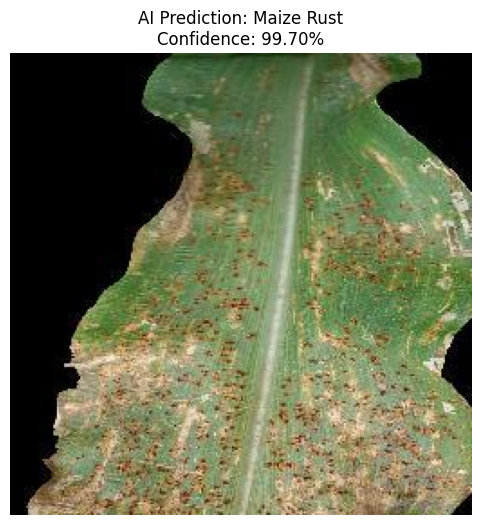

🌿 Analysis complete. This leaf shows signs of: maize_rust


('maize_rust', 99.69680905342102)

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def predict_single_image(image_path):
    # 1. Define the categories (Must be in this exact order)
    class_names = ['bean_spot', 'cassava_mosaic', 'maize_blight', 'maize_healthy', 'maize_rust']

    # 2. Setup the same preprocessing as training
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 3. Load and transform the image
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    # 4. Run Inference
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        # Apply Softmax to get probabilities (0.0 to 1.0)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, pred_idx = torch.max(probabilities, 1)

    # 5. Display the result
    result_label = class_names[pred_idx.item()]
    result_conf = confidence.item() * 100

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"AI Prediction: {result_label.replace('_', ' ').title()}\nConfidence: {result_conf:.2f}%")
    plt.axis('off')
    plt.show()

    print(f"🌿 Analysis complete. This leaf shows signs of: {result_label}")
    return result_label, result_conf

# --- EXECUTION ---
# Pick an image path from your test folder to try it out!
test_path = "/content/ktt/data/mini_plant_set/maize_rust/49339.jpg"
predict_single_image(test_path)